# Experiment 002 — Handling Class Imbalance

**Goal:** Test 4 methods for handling the imbalanced dataset (62% Not Survived / 38% Survived) and compare which improves recall on the Survived class without sacrificing overall AUC.

**Baseline from exp_001:** ROC-AUC 0.874 (CV), Recall on Survived 0.68

**Methods tested:**
1. `class_weight='balanced'` — penalise minority class misclassification
2. Random oversampling — duplicate minority class rows
3. Random undersampling — remove majority class rows
4. SMOTE — synthesise new minority class samples

## 1. Imports

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import roc_auc_score, classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
import shap

pd.set_option('display.max_columns', None)
%matplotlib inline

## 2. Load & Preprocess (same pipeline as exp_001)

In [30]:
df = pd.read_csv('../../data/raw/train.csv')

# Extract helper features
df = df.drop(columns=['PassengerId'])
df['Name_title']       = df['Name'].str.extract(r',\s*([^.]+)\.')
df['Cabin_deck']       = df['Cabin'].str[0]
df['Ticket_is_numeric'] = df['Ticket'].str.match(r'^\d+$')
df = df.drop(columns=['Name', 'Ticket', 'Cabin'])

print(f'Shape: {df.shape}')
print(f'Survival rate: {df["Survived"].mean():.2%}')

Shape: (891, 11)
Survival rate: 38.38%


In [31]:
# Train / test split
X = df.drop(columns=['Survived'])
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')
print(f'Train survival rate: {y_train.mean():.2%} | Test: {y_test.mean():.2%}')

Train: 712 | Test: 179
Train survival rate: 38.34% | Test: 38.55%


In [32]:
# Impute (fit on train only)
X_train = X_train.copy()
X_test  = X_test.copy()

age_median    = X_train['Age'].median()
embarked_mode = X_train['Embarked'].mode()[0]

X_train['Age']        = X_train['Age'].fillna(age_median)
X_test['Age']         = X_test['Age'].fillna(age_median)
X_train['Embarked']   = X_train['Embarked'].fillna(embarked_mode)
X_test['Embarked']    = X_test['Embarked'].fillna(embarked_mode)
X_train['Cabin_deck'] = X_train['Cabin_deck'].fillna('Unknown')
X_test['Cabin_deck']  = X_test['Cabin_deck'].fillna('Unknown')

# Encode
encode_cols = ['Sex', 'Embarked', 'Name_title', 'Cabin_deck']
X_train = pd.get_dummies(X_train, columns=encode_cols, drop_first=True)
X_test  = pd.get_dummies(X_test,  columns=encode_cols, drop_first=True)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# Scale (fit on train only)
num_scale_cols = ['Age', 'Fare', 'SibSp', 'Parch']
scaler = StandardScaler()
X_train[num_scale_cols] = scaler.fit_transform(X_train[num_scale_cols])
X_test[num_scale_cols]  = scaler.transform(X_test[num_scale_cols])

print(f'Features: {X_train.shape[1]} | Nulls: {X_train.isnull().sum().sum()}')

Features: 30 | Nulls: 0


## 3. Imbalance Handling — Method Comparison

In [33]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

methods = {
    'Baseline (no balancing)':   (X_train, y_train, RandomForestClassifier(n_estimators=100, random_state=42)),
    'class_weight=balanced':     (X_train, y_train, RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')),
    'Random Oversampling':        (X_train, y_train, RandomForestClassifier(n_estimators=100, random_state=42)),
    'Random Undersampling':       (X_train, y_train, RandomForestClassifier(n_estimators=100, random_state=42)),
    'SMOTE':                      (X_train, y_train, RandomForestClassifier(n_estimators=100, random_state=42)),
}

# Apply resampling to train sets
X_over,  y_over  = RandomOverSampler(random_state=42).fit_resample(X_train, y_train)
X_under, y_under = RandomUnderSampler(random_state=42).fit_resample(X_train, y_train)
X_smote, y_smote = SMOTE(random_state=42).fit_resample(X_train, y_train)

methods['Random Oversampling']  = (X_over,  y_over,  RandomForestClassifier(n_estimators=100, random_state=42))
methods['Random Undersampling'] = (X_under, y_under, RandomForestClassifier(n_estimators=100, random_state=42))
methods['SMOTE']                 = (X_smote, y_smote, RandomForestClassifier(n_estimators=100, random_state=42))

print('Train set sizes after resampling:')
print(f'  Original:    {len(y_train)} | Class balance: {y_train.mean():.2%}')
print(f'  Oversample:  {len(y_over)}  | Class balance: {y_over.mean():.2%}')
print(f'  Undersample: {len(y_under)} | Class balance: {y_under.mean():.2%}')
print(f'  SMOTE:       {len(y_smote)} | Class balance: {y_smote.mean():.2%}')

Train set sizes after resampling:
  Original:    712 | Class balance: 38.34%
  Oversample:  878  | Class balance: 50.00%
  Undersample: 546 | Class balance: 50.00%
  SMOTE:       878 | Class balance: 50.00%


In [34]:
results = []
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rf_params = dict(n_estimators=100, random_state=42)

# CV pipelines — resampling happens INSIDE each fold, no leakage
cv_pipelines = {
    'Baseline (no balancing)':  ImbPipeline([('clf', RandomForestClassifier(**rf_params))]),
    'class_weight=balanced':    ImbPipeline([('clf', RandomForestClassifier(**rf_params, class_weight='balanced'))]),
    'Random Oversampling':      ImbPipeline([('sampler', RandomOverSampler(random_state=42)),  ('clf', RandomForestClassifier(**rf_params))]),
    'Random Undersampling':     ImbPipeline([('sampler', RandomUnderSampler(random_state=42)), ('clf', RandomForestClassifier(**rf_params))]),
    'SMOTE':                    ImbPipeline([('sampler', SMOTE(random_state=42)),              ('clf', RandomForestClassifier(**rf_params))]),
}

for name, (X_tr, y_tr, clf) in methods.items():
    # Hold-out: train on full resampled train set, evaluate on original test set
    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)[:, 1]
    report = classification_report(y_test, y_pred, output_dict=True)

    # CV: resampling applied inside each fold via ImbPipeline — no leakage
    cv_auc = cross_val_score(cv_pipelines[name], X_train, y_train, cv=skf, scoring='roc_auc').mean()

    results.append({
        'Method':               name,
        'Hold-out AUC':         round(roc_auc_score(y_test, y_prob), 4),
        'CV AUC':               round(cv_auc, 4),
        'Precision (Survived)': round(report['1']['precision'], 3),
        'Recall (Survived)':    round(report['1']['recall'], 3),
        'F1 (Survived)':        round(report['1']['f1-score'], 3),
        'Accuracy':             round(report['accuracy'], 3),
    })

results_df = pd.DataFrame(results).set_index('Method')
results_df

,Hold-out AUC,CV AUC,Precision (Survived),Recall (Survived),F1 (Survived),Accuracy
Method,,,,,,
Baseline (no balancing),0.8282,0.8773,0.746,0.681,0.712,0.788
class_weight=balanced,0.8244,0.8782,0.766,0.710,0.737,0.804
Random Oversampling,0.8119,0.8741,0.662,0.710,0.685,0.749
Random Undersampling,0.8237,0.8724,0.631,0.768,0.693,0.737
SMOTE,0.8230,0.8731,0.689,0.739,0.713,0.771


## 4. Visualise Comparison

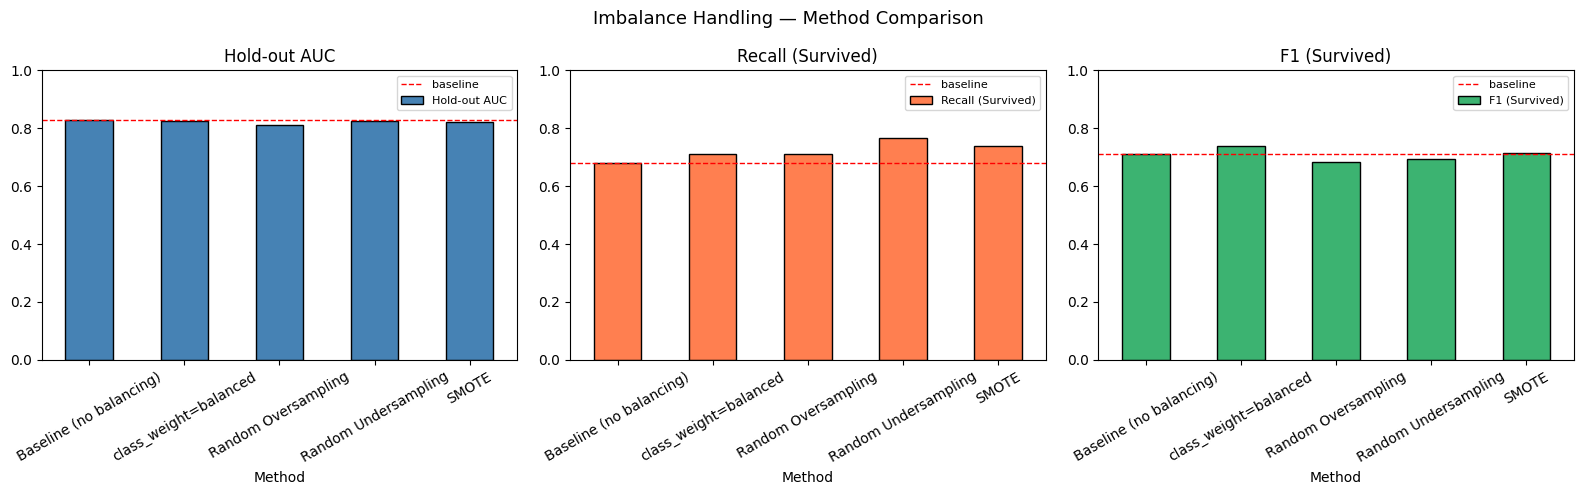

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = ['Hold-out AUC', 'Recall (Survived)', 'F1 (Survived)']
colors  = ['steelblue', 'coral', 'mediumseagreen']

for ax, metric, color in zip(axes, metrics, colors):
    results_df[metric].plot(kind='bar', ax=ax, color=color, edgecolor='black')
    ax.set_title(metric)
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=30)
    ax.axhline(results_df.loc['Baseline (no balancing)', metric],
               color='red', linestyle='--', linewidth=1, label='baseline')
    ax.legend(fontsize=8)

plt.suptitle('Imbalance Handling — Method Comparison', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Best Method — Detailed Report

Best method by F1 (Survived): class_weight=balanced

ROC-AUC: 0.8244

              precision    recall  f1-score   support

Not Survived       0.83      0.86      0.84       110
    Survived       0.77      0.71      0.74        69

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



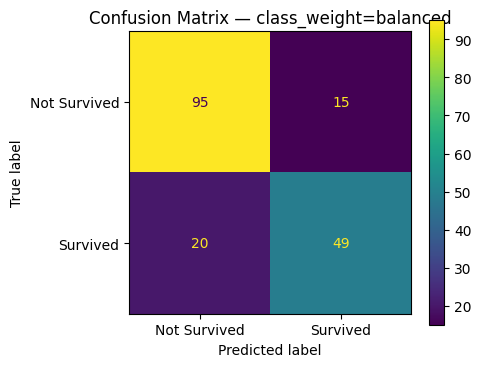

In [36]:
# Pick method with best F1 (Survived) — balances precision and recall
best_method = results_df['F1 (Survived)'].idxmax()
print(f'Best method by F1 (Survived): {best_method}')

X_best, y_best, clf_best = methods[best_method]
clf_best.fit(X_best, y_best)

y_pred = clf_best.predict(X_test)
y_prob = clf_best.predict_proba(X_test)[:, 1]

print(f'\nROC-AUC: {roc_auc_score(y_test, y_prob):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Not Survived', 'Survived']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_estimator(clf_best, X_test, y_test,
                                      display_labels=['Not Survived', 'Survived'], ax=ax)
plt.title(f'Confusion Matrix — {best_method}')
plt.tight_layout()
plt.show()